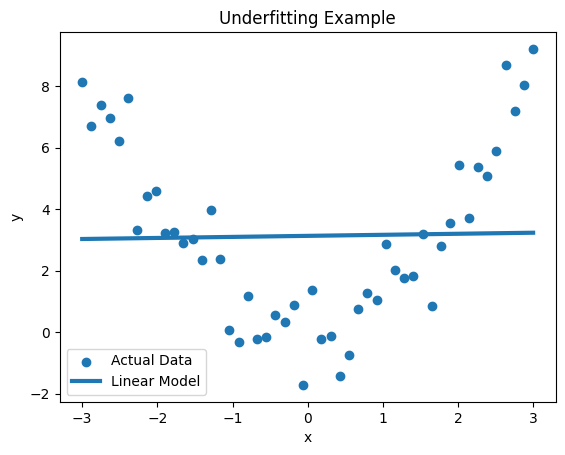

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate data
x = np.linspace(-3,3,50)
y = x**2 + np.random.normal(0,1,50)

# reshape for sklearn
X = x.reshape(-1,1)

# Train linear regression (simple model)
model = LinearRegression()
model.fit(X,y)

# predictions
y_pred = model.predict(X)

# Plot
plt.scatter(x,y,label="Actual Data")
plt.plot(x,y_pred,label="Linear Model",linewidth=3)

plt.title("Underfitting Example")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

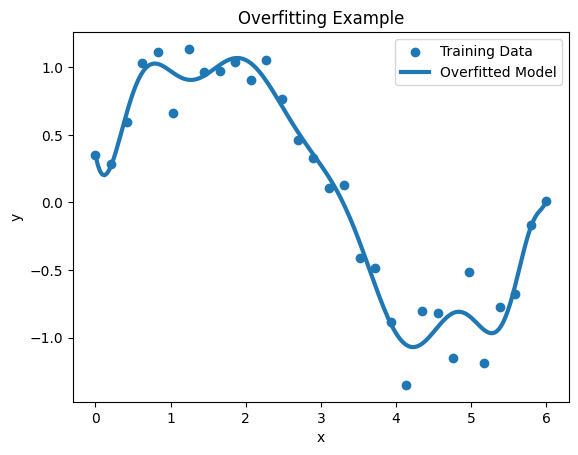

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(0)

# Generate data
X = np.linspace(0,6,30)
y = np.sin(X) + np.random.normal(0,0.2,30)

X = X.reshape(-1,1)

# Create high degree polynomial (overfitting)
poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly,y)

# Predictions
x_test = np.linspace(0,6,200).reshape(-1,1)
x_test_poly = poly.transform(x_test)
y_pred = model.predict(x_test_poly)

# Plot
plt.scatter(X,y,label="Training Data")
plt.plot(x_test,y_pred,label="Overfitted Model",linewidth=3)

plt.title("Overfitting Example")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

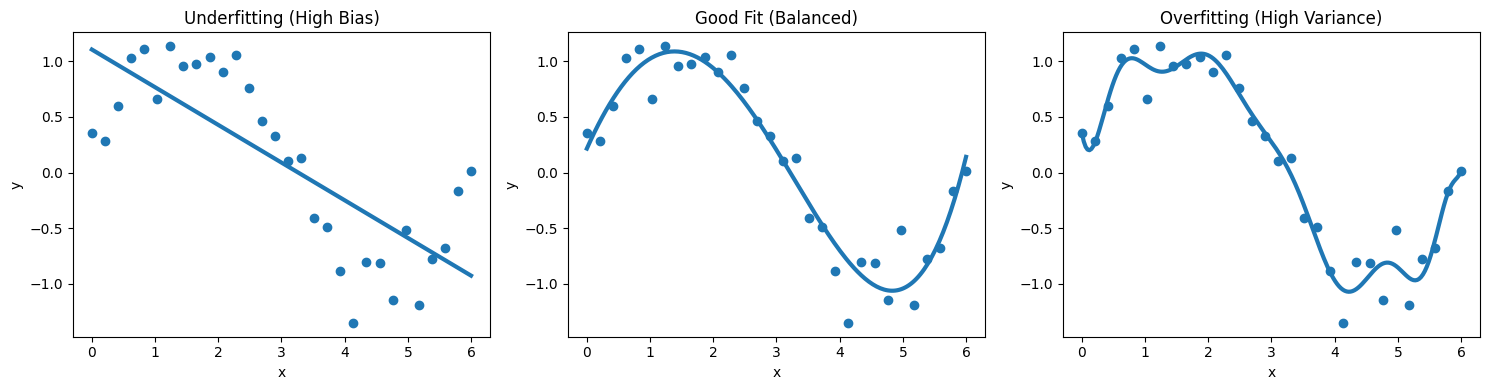

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)

X = np.linspace(0,6,30)
y = np.sin(X) + np.random.normal(0,0.2,30)

X = X.reshape(-1,1)

# Points for smooth plotting
X_test = np.linspace(0,6,200).reshape(-1,1)

# Polynomial degrees
degrees = [1,4,15]

titles = ["Underfitting (High Bias)",
          "Good Fit (Balanced)",
          "Overfitting (High Variance)"]

plt.figure(figsize=(15,4))

for i,deg in enumerate(degrees):

    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_poly,y)

    y_pred = model.predict(X_test_poly)

    plt.subplot(1,3,i+1)

    plt.scatter(X,y,label="Data")
    plt.plot(X_test,y_pred,label="Model",linewidth=3)

    plt.title(titles[i])
    plt.xlabel("x")
    plt.ylabel("y")

plt.tight_layout()
plt.show()

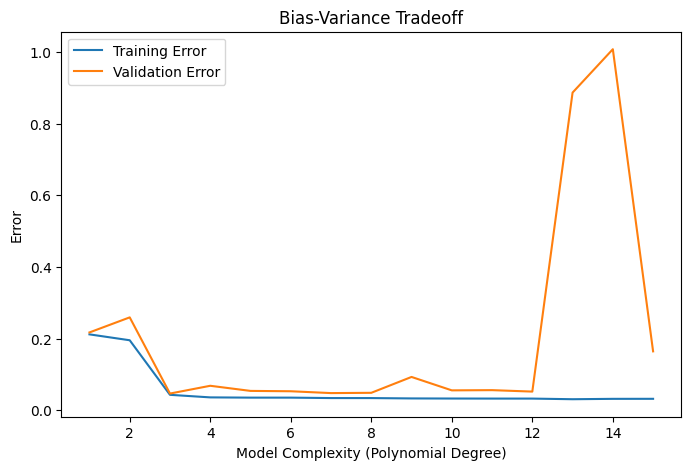

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Generate dataset
np.random.seed(0)

X = np.linspace(0,6,60)
y = np.sin(X) + np.random.normal(0,0.2,60)

X = X.reshape(-1,1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

degrees = range(1,16)

train_errors = []
test_errors = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot
plt.figure(figsize=(8,5))

plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, test_errors, label="Validation Error")

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Error")

plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Generate synthetic binary dataset
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, flip_y=0.1, random_state=0)

# Logistic Regression without regularization
model_no_reg = LogisticRegression(penalty='none', solver='newton-cg')
model_no_reg.fit(X, y)

# Logistic Regression with L2 regularization
model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs')
model_l2.fit(X, y)

# Logistic Regression with L1 regularization
model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear')
model_l1.fit(X, y)

# Print weights
print("No Regularization weights:", model_no_reg.coef_)
print("L2 Regularization weights:", model_l2.coef_)
print("L1 Regularization weights:", model_l1.coef_)

InvalidParameterError: The 'penalty' parameter of LogisticRegression must be a str among {'l2', 'l1', 'elasticnet'} or None. Got 'none' instead.